# WC2026 Match Prediction + Full Bracket Simulator

Trains XGBoost on 49K historical matches → predicts all unplayed WC2026 matches → simulates the complete bracket.

## 0 — Imports & Data Loading

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import seaborn as sns
import warnings
import urllib.request
from io import BytesIO
from collections import defaultdict, deque
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, f1_score
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

TEAM_TO_CODE = {
    'England': 'gb-eng', 'Scotland': 'gb-sct', 'Wales': 'gb-wls', 'Northern Ireland': 'gb-nir',
    'United States': 'us', 'Canada': 'ca', 'Mexico': 'mx', 'Panama': 'pa',
    'Costa Rica': 'cr', 'Honduras': 'hn', 'Jamaica': 'jm', 'El Salvador': 'sv',
    'Guatemala': 'gt', 'Haiti': 'ht', 'Trinidad and Tobago': 'tt', 'Cuba': 'cu',
    'Suriname': 'sr', 'Guyana': 'gy', 'Belize': 'bz',
    'Argentina': 'ar', 'Brazil': 'br', 'Colombia': 'co', 'Uruguay': 'uy',
    'Chile': 'cl', 'Peru': 'pe', 'Ecuador': 'ec', 'Venezuela': 've',
    'Paraguay': 'py', 'Bolivia': 'bo',
    'France': 'fr', 'Germany': 'de', 'Spain': 'es', 'Portugal': 'pt',
    'Netherlands': 'nl', 'Belgium': 'be', 'Italy': 'it', 'Croatia': 'hr',
    'Switzerland': 'ch', 'Serbia': 'rs', 'Denmark': 'dk', 'Austria': 'at',
    'Turkey': 'tr', 'Turkiye': 'tr', 'Ukraine': 'ua', 'Poland': 'pl',
    'Czech Republic': 'cz', 'Czechia': 'cz', 'Slovakia': 'sk', 'Romania': 'ro',
    'Slovenia': 'si', 'Albania': 'al', 'Georgia': 'ge', 'North Macedonia': 'mk',
    'Kosovo': 'xk', 'Republic of Ireland': 'ie', 'Ireland': 'ie',
    'Sweden': 'se', 'Norway': 'no', 'Finland': 'fi', 'Iceland': 'is',
    'Greece': 'gr', 'Bulgaria': 'bg', 'Bosnia and Herzegovina': 'ba',
    'Montenegro': 'me', 'Luxembourg': 'lu', 'Belarus': 'by', 'Moldova': 'md',
    'Lithuania': 'lt', 'Latvia': 'lv', 'Estonia': 'ee', 'Armenia': 'am',
    'Azerbaijan': 'az', 'Kazakhstan': 'kz', 'Russia': 'ru', 'Cyprus': 'cy',
    'Malta': 'mt', 'Andorra': 'ad', 'San Marino': 'sm', 'Faroe Islands': 'fo',
    'Japan': 'jp', 'South Korea': 'kr', 'Australia': 'au', 'Iran': 'ir',
    'Saudi Arabia': 'sa', 'Qatar': 'qa', 'Iraq': 'iq', 'China': 'cn', 'China PR': 'cn',
    'Uzbekistan': 'uz', 'Jordan': 'jo', 'UAE': 'ae', 'United Arab Emirates': 'ae',
    'Indonesia': 'id', 'Thailand': 'th', 'Vietnam': 'vn', 'Palestine': 'ps',
    'India': 'in', 'Kuwait': 'kw', 'Kyrgyzstan': 'kg', 'Syria': 'sy',
    'Lebanon': 'lb', 'North Korea': 'kp', 'Tajikistan': 'tj', 'Malaysia': 'my',
    'Philippines': 'ph', 'Singapore': 'sg', 'Myanmar': 'mm',
    'Morocco': 'ma', 'Senegal': 'sn', 'Ghana': 'gh', 'Cameroon': 'cm',
    'Nigeria': 'ng', 'Egypt': 'eg', 'Algeria': 'dz',
    "Cote d'Ivoire": 'ci', 'Ivory Coast': 'ci', 'Tunisia': 'tn',
    'South Africa': 'za', 'DR Congo': 'cd', 'Democratic Republic of the Congo': 'cd',
    'Mali': 'ml', 'Burkina Faso': 'bf', 'Zambia': 'zm', 'Zimbabwe': 'zw',
    'Kenya': 'ke', 'Uganda': 'ug', 'Ethiopia': 'et', 'Angola': 'ao',
    'Guinea': 'gn', 'Cape Verde': 'cv', 'Gambia': 'gm', 'Gabon': 'ga',
    'Libya': 'ly', 'Comoros': 'km', 'Madagascar': 'mg', 'Namibia': 'na',
    'Togo': 'tg', 'Benin': 'bj', 'Sierra Leone': 'sl', 'Liberia': 'lr',
    'Niger': 'ne', 'Guinea-Bissau': 'gw', 'Rwanda': 'rw', 'Malawi': 'mw',
    'Botswana': 'bw', 'South Sudan': 'ss', 'Chad': 'td',
    'New Zealand': 'nz', 'Fiji': 'fj', 'Papua New Guinea': 'pg',
    'Solomon Islands': 'sb', 'Vanuatu': 'vu', 'New Caledonia': 'nc',
    'Curacao': 'cw', 'Curaçao': 'cw',
}

_flag_cache = {}
def get_flag_img(team, size='32x24'):
    code = TEAM_TO_CODE.get(team, '').lower()
    if not code:
        return None
    key = f'{code}@{size}'
    if key in _flag_cache:
        return _flag_cache[key]
    try:
        url = f'https://flagcdn.com/{size}/{code}.png'
        with urllib.request.urlopen(url, timeout=4) as r:
            img = mpimg.imread(BytesIO(r.read()), format='png')
        _flag_cache[key] = img
    except Exception:
        _flag_cache[key] = None
    return _flag_cache[key]

results_raw = pd.read_csv('results.csv')
results = results_raw.copy()
results['home_score'] = pd.to_numeric(results['home_score'], errors='coerce')
results['away_score'] = pd.to_numeric(results['away_score'], errors='coerce')
results = results.dropna(subset=['home_score', 'away_score']).reset_index(drop=True)
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)
results['date'] = pd.to_datetime(results['date'])
results['neutral'] = results['neutral'].map({'TRUE': True, 'FALSE': False, True: True, False: False}).astype(bool)
results['year'] = results['date'].dt.year

def categorise(t):
    t = str(t)
    if 'FIFA World Cup' in t: return 'FIFA World Cup'
    if 'UEFA' in t:           return 'UEFA'
    if 'Copa' in t:           return 'CONMEBOL'
    if 'CONMEBOL' in t:       return 'CONMEBOL'
    if 'African Cup' in t or 'AFCON' in t: return 'CAF'
    if 'Friendly' in t:       return 'Friendly'
    return 'Other'

results['category'] = results['tournament'].apply(categorise)
results['result'] = 'draw'
results.loc[results['home_score'] > results['away_score'], 'result'] = 'home_win'
results.loc[results['home_score'] < results['away_score'], 'result'] = 'away_win'
print(f"Loaded {len(results):,} matches  ({results['year'].min()}–{results['year'].max()})")

Loaded 49,459 matches  (1872–2026)


## 1 — ELO Snapshots + Rolling Form

In [2]:
# ELO computation — capture rating BEFORE each match update (no leakage)
K_MAP = {'FIFA World Cup': 60, 'UEFA': 40, 'CONMEBOL': 40, 'CAF': 40, 'Other': 35, 'Friendly': 20}

elo_current = {}
team_history = defaultdict(lambda: deque(maxlen=10))

def _elo(team):
    return elo_current.setdefault(team, 1500.0)

results_sorted = results.sort_values('date').reset_index(drop=True)
rows = results_sorted[['date','home_team','away_team','result','neutral','category',
                        'home_score','away_score']].to_dict('records')

home_elo_snap, away_elo_snap = [], []
home_wr, home_gf_avg, home_ga_avg = [], [], []
away_wr, away_gf_avg, away_ga_avg = [], [], []

def _form(hist):
    if not hist:
        return 0.40, 1.30, 1.10
    wr  = sum(r['w']  for r in hist) / len(hist)
    gf  = sum(r['gf'] for r in hist) / len(hist)
    ga  = sum(r['ga'] for r in hist) / len(hist)
    return wr, gf, ga

for row in rows:
    h, a = row['home_team'], row['away_team']
    eh, ea = _elo(h), _elo(a)

    home_elo_snap.append(eh);  away_elo_snap.append(ea)

    hf = _form(team_history[h]);  af = _form(team_history[a])
    home_wr.append(hf[0]);  home_gf_avg.append(hf[1]);  home_ga_avg.append(hf[2])
    away_wr.append(af[0]);  away_gf_avg.append(af[1]);  away_ga_avg.append(af[2])

    bonus = 0 if row['neutral'] else 100
    exp_h = 1 / (1 + 10 ** ((ea - (eh + bonus)) / 400))
    if row['result'] == 'home_win':   ah, aa = 1, 0
    elif row['result'] == 'away_win': ah, aa = 0, 1
    else:                             ah, aa = 0.5, 0.5
    K = K_MAP.get(row['category'], 30)
    elo_current[h] = eh + K * (ah - exp_h)
    elo_current[a] = ea + K * (aa - (1 - exp_h))

    team_history[h].append({'w': int(row['result']=='home_win'), 'gf': row['home_score'], 'ga': row['away_score']})
    team_history[a].append({'w': int(row['result']=='away_win'), 'gf': row['away_score'], 'ga': row['home_score']})

results_sorted['home_elo']       = home_elo_snap
results_sorted['away_elo']       = away_elo_snap
results_sorted['elo_diff']       = results_sorted['home_elo'] - results_sorted['away_elo']
results_sorted['home_wr10']      = home_wr
results_sorted['home_gf10']      = home_gf_avg
results_sorted['home_ga10']      = home_ga_avg
results_sorted['away_wr10']      = away_wr
results_sorted['away_gf10']      = away_gf_avg
results_sorted['away_ga10']      = away_ga_avg

top10 = pd.Series(elo_current).sort_values(ascending=False).head(10)
print("Final ELO top 10:")
print(top10.to_string())

Final ELO top 10:
Argentina    2090.020825
Spain        2071.737915
France       2049.739181
England      1986.271687
Brazil       1980.054615
Colombia     1973.293745
Germany      1958.452353
Morocco      1954.667808
Portugal     1953.935444
Japan        1938.181385


## 2 — Feature Assembly & Temporal Split

In [3]:
# Feature matrix + temporal split
CAT_ENC = {'FIFA World Cup': 0, 'UEFA': 1, 'CONMEBOL': 2, 'CAF': 3, 'Other': 4, 'Friendly': 5}

results_sorted['cat_enc']   = results_sorted['category'].map(CAT_ENC).fillna(4).astype(int)
results_sorted['neutral_i'] = results_sorted['neutral'].astype(int)
results_sorted['month']     = results_sorted['date'].dt.month

def label(r):
    if r.home_score > r.away_score: return 0
    if r.home_score == r.away_score: return 1
    return 2
results_sorted['target'] = results_sorted.apply(label, axis=1)

FEATS = ['home_elo','away_elo','elo_diff',
         'home_wr10','home_gf10','home_ga10',
         'away_wr10','away_gf10','away_ga10',
         'neutral_i','cat_enc','month','year']

train = results_sorted[results_sorted['year'] <= 2021]
val   = results_sorted[(results_sorted['year'] >= 2022) & (results_sorted['year'] <= 2023)]
X_tr, y_tr = train[FEATS].values, train['target'].values
X_va, y_va = val[FEATS].values,   val['target'].values
print(f"Train: {len(X_tr):,}  |  Val: {len(X_va):,}")
vc = pd.Series(y_tr).value_counts().sort_index()
print(f"Class dist (train) — 0=home_win:{vc[0]}  1=draw:{vc[1]}  2=away_win:{vc[2]}")

Train: 44,837  |  Val: 2,024
Class dist (train) — 0=home_win:22029  1=draw:10186  2=away_win:12622


## 3 — Model Training (Logistic Regression + XGBoost)

              Model  Accuracy  Log-loss  F1 macro
Logistic Regression    0.5375    0.9369    0.5115
            XGBoost    0.5973    0.8933    0.4357


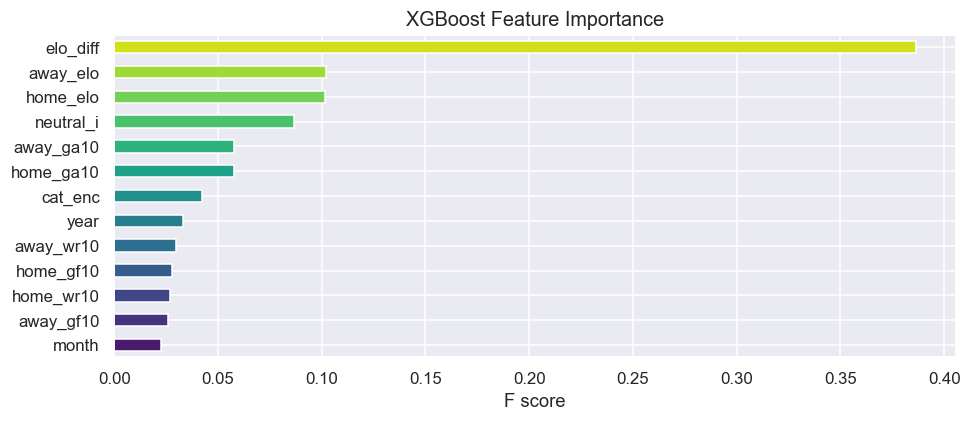

In [4]:
# Logistic Regression
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_tr)
Xva_sc = scaler.transform(X_va)

lr = LogisticRegression(multi_class='multinomial', max_iter=1000, class_weight='balanced', C=0.8)
lr.fit(Xtr_sc, y_tr)
lr_pred = lr.predict(Xva_sc)
lr_prob = lr.predict_proba(Xva_sc)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', early_stopping_rounds=25, verbosity=0,
)
xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
xgb_pred = xgb_model.predict(X_va)
xgb_prob = xgb_model.predict_proba(X_va)

results_table = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Accuracy': [accuracy_score(y_va, lr_pred), accuracy_score(y_va, xgb_pred)],
    'Log-loss': [log_loss(y_va, lr_prob),       log_loss(y_va, xgb_prob)],
    'F1 macro': [f1_score(y_va, lr_pred, average='macro'), f1_score(y_va, xgb_pred, average='macro')],
}).round(4)
print(results_table.to_string(index=False))

# Feature importance plot
fi = pd.Series(xgb_model.feature_importances_, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
fi.plot.barh(ax=ax, color=sns.color_palette('viridis', len(fi)))
ax.set_title('XGBoost Feature Importance', fontsize=13)
ax.set_xlabel('F score')
plt.tight_layout(); plt.show()

## 4 — Prediction Helper Functions

In [5]:
# Prediction helper — build feature vector for any upcoming match
def _team_form(team):
    hist = team_history.get(team)
    if not hist:
        return 0.40, 1.30, 1.10
    wr  = sum(r['w']  for r in hist) / len(hist)
    gf  = sum(r['gf'] for r in hist) / len(hist)
    ga  = sum(r['ga'] for r in hist) / len(hist)
    return wr, gf, ga

def predict_probs(home, away, neutral=True, cat_enc=0, month=7, year=2026):
    # returns [P(home_win), P(draw), P(away_win)]
    he = elo_current.get(home, 1500.0)
    ae = elo_current.get(away, 1500.0)
    hf = _team_form(home);  af = _team_form(away)
    X = np.array([[he, ae, he-ae,
                   hf[0], hf[1], hf[2],
                   af[0], af[1], af[2],
                   int(neutral), cat_enc, month, year]])
    return xgb_model.predict_proba(X)[0]  # [p_hw, p_draw, p_aw]

def ko_winner(home, away, neutral=True, cat_enc=0, month=7, year=2026):
    # predict knockout winner (no draws)
    p = predict_probs(home, away, neutral, cat_enc, month, year)
    return home if p[0] >= p[2] else away, p

# quick sanity check
p = predict_probs('Argentina', 'Brazil', neutral=True)
print(f"Argentina vs Brazil  — home_win:{p[0]:.1%}  draw:{p[1]:.1%}  away_win:{p[2]:.1%}")
p2 = predict_probs('France', 'Germany', neutral=True)
print(f"France vs Germany    — home_win:{p2[0]:.1%}  draw:{p2[1]:.1%}  away_win:{p2[2]:.1%}")

Argentina vs Brazil  — home_win:42.7%  draw:28.4%  away_win:28.9%


France vs Germany    — home_win:40.2%  draw:28.3%  away_win:31.5%


## 5 — WC2026 Group Stage Predictions

In [6]:
# Load WC2026 data
wc = pd.read_csv('data/worldcup2026_clean.csv')
wc['match_datetime'] = pd.to_datetime(wc['match_datetime'])
wc['finished'] = wc['finished'].map({True: True, False: False, 'True': True, 'False': False})
wc['match_id'] = wc['match_id'].astype(int)

group_matches = wc[wc['type'] == 'group'].copy()
finished_group = group_matches[group_matches['finished'] == True].copy()
pending_group  = group_matches[group_matches['finished'] == False].copy()

print(f"Group matches finished : {len(finished_group)}")
print(f"Group matches pending  : {len(pending_group)}")
print(f"Knockout matches       : {len(wc[wc['type'] != 'group'])}")

# ── Update ELO + rolling form with finished WC2026 matches ────────────────
# All WC2026 matches are neutral — USA/Canada/Mexico are hosts but a World Cup
# is always treated as a neutral-venue tournament; giving them home advantage
# would artificially inflate their ELO and skew every remaining prediction.
print("\nUpdating ELO with finished WC2026 group matches (neutral=True for all)…")
for _, row in finished_group.sort_values('match_datetime').iterrows():
    h, a = row['home_team'], row['away_team']
    eh, ea = elo_current.get(h, 1500.0), elo_current.get(a, 1500.0)
    exp_h = 1 / (1 + 10 ** ((ea - eh) / 400))   # bonus=0: fully neutral
    res = row['match_result']
    if res == 'home_win':   ah, aa = 1, 0
    elif res == 'away_win': ah, aa = 0, 1
    else:                   ah, aa = 0.5, 0.5
    elo_current[h] = eh + 60 * (ah - exp_h)
    elo_current[a] = ea + 60 * (aa - (1 - exp_h))
    # Update rolling form so remaining predictions see actual WC group form
    team_history[h].append({'w': int(res == 'home_win'),
                             'gf': int(row['home_score']), 'ga': int(row['away_score'])})
    team_history[a].append({'w': int(res == 'away_win'),
                             'gf': int(row['away_score']), 'ga': int(row['home_score'])})

top10_post = pd.Series(elo_current).sort_values(ascending=False).head(10)
print("ELO top 10 after WC2026 group stage:")
print(top10_post.to_string())

# ── Predict the 12 remaining group matches ────────────────────────────────
pending_preds = []
for _, row in pending_group.iterrows():
    p = predict_probs(row['home_team'], row['away_team'])   # neutral=True default
    if p[0] > p[1] and p[0] > p[2]:   res = 'home_win'
    elif p[2] > p[0] and p[2] > p[1]: res = 'away_win'
    else:                               res = 'draw'
    pending_preds.append({
        'match_id': row['match_id'], 'group': row['group'], 'matchday': row['matchday'],
        'match_datetime': row['match_datetime'],
        'home_team': row['home_team'], 'away_team': row['away_team'],
        'home_score': None, 'away_score': None,
        'match_result': res, 'finished': False,
        'prob_hw': p[0], 'prob_d': p[1], 'prob_aw': p[2],
    })
    print(f"  {row['home_team']:35s} vs {row['away_team']:25s}  →  {res}  ({p[0]:.0%}/{p[1]:.0%}/{p[2]:.0%})")

pending_pred_df = pd.DataFrame(pending_preds)
# Add prob columns to finished too (for chart colouring)
for col in ['prob_hw','prob_d','prob_aw']:
    finished_group[col] = np.nan


Group matches finished : 60
Group matches pending  : 12
Knockout matches       : 32

Updating ELO with finished WC2026 group matches (neutral=True for all)…
ELO top 10 after WC2026 group stage:
Argentina      2112.105725
France         2069.075310
Spain          2055.041043
Brazil         1999.097785
Colombia       1990.414062
England        1989.188795
Morocco        1980.985878
Mexico         1974.926892
Norway         1962.879885
Netherlands    1961.906362
  Senegal                             vs Iraq                       →  home_win  (52%/26%/22%)
  Panama                              vs England                    →  away_win  (8%/20%/72%)
  Democratic Republic of the Congo    vs Uzbekistan                 →  away_win  (17%/24%/60%)
  Norway                              vs France                     →  away_win  (26%/25%/49%)
  Egypt                               vs Iran                       →  away_win  (35%/30%/36%)
  Cape Verde                          vs Saudi Arabia         

## 6 — Group Standings (Actual + Predicted)

In [7]:
# Build complete group standings (actual + predicted)
def build_standings(df_finished, df_predicted=None):
    # Aggregate rows -> standings dict keyed by group
    rows = []
    for _, m in df_finished.iterrows():
        res = m['match_result']
        h_pts = 3 if res=='home_win' else (1 if res=='draw' else 0)
        a_pts = 3 if res=='away_win' else (1 if res=='draw' else 0)
        rows += [
            {'group': m['group'], 'team': m['home_team'], 'pts': h_pts,
             'w': int(res=='home_win'), 'd': int(res=='draw'), 'l': int(res=='away_win'),
             'gf': (int(m['home_score']) if pd.notna(m.get('home_score')) else 0),
             'ga': (int(m['away_score']) if pd.notna(m.get('away_score')) else 0)},
            {'group': m['group'], 'team': m['away_team'], 'pts': a_pts,
             'w': int(res=='away_win'), 'd': int(res=='draw'), 'l': int(res=='home_win'),
             'gf': (int(m['away_score']) if pd.notna(m.get('away_score')) else 0),
             'ga': (int(m['home_score']) if pd.notna(m.get('home_score')) else 0)},
        ]
    if df_predicted is not None and len(df_predicted):
        for _, m in df_predicted.iterrows():
            res = m['match_result']
            h_pts = 3 if res=='home_win' else (1 if res=='draw' else 0)
            a_pts = 3 if res=='away_win' else (1 if res=='draw' else 0)
            rows += [
                {'group': m['group'], 'team': m['home_team'], 'pts': h_pts,
                 'w': int(res=='home_win'), 'd': int(res=='draw'), 'l': int(res=='away_win'),
                 'gf': 0, 'ga': 0},
                {'group': m['group'], 'team': m['away_team'], 'pts': a_pts,
                 'w': int(res=='away_win'), 'd': int(res=='draw'), 'l': int(res=='home_win'),
                 'gf': 0, 'ga': 0},
            ]
    s = pd.DataFrame(rows)
    s = s.groupby(['group','team']).sum().reset_index()
    s['gd'] = s['gf'] - s['ga']
    s['mp'] = s['w'] + s['d'] + s['l']
    result = {}
    for grp, grp_df in s.groupby('group'):
        result[grp] = grp_df.sort_values(['pts','gd','gf'], ascending=False).reset_index(drop=True)
    return result

standings = build_standings(finished_group, pending_pred_df)

# Group qualifiers
group_winners  = {g: s.iloc[0]['team'] for g, s in standings.items()}
group_runners  = {g: s.iloc[1]['team'] for g, s in standings.items()}
group_thirds   = {g: {'team': s.iloc[2]['team'], 'pts': s.iloc[2]['pts'],
                       'gd': s.iloc[2]['gd'], 'gf': s.iloc[2]['gf']}
                  for g, s in standings.items() if len(s) >= 3}

thirds_ranked = sorted(group_thirds.items(), key=lambda x: (-x[1]['pts'], -x[1]['gd'], -x[1]['gf']))
best8_groups  = [g for g, _ in thirds_ranked[:8]]
best8_teams   = {g: group_thirds[g]['team'] for g in best8_groups}

print("Group Winners :", group_winners)
print("Group Runners :", group_runners)
print("Best 8 thirds :", best8_teams)

Group Winners : {'A': 'Mexico', 'B': 'Switzerland', 'C': 'Brazil', 'D': 'United States', 'E': 'Germany', 'F': 'Netherlands', 'G': 'Iran', 'H': 'Spain', 'I': 'France', 'J': 'Argentina', 'K': 'Colombia', 'L': 'England'}
Group Runners : {'A': 'South Africa', 'B': 'Canada', 'C': 'Morocco', 'D': 'Australia', 'E': 'Ivory Coast', 'F': 'Japan', 'G': 'Belgium', 'H': 'Cape Verde', 'I': 'Norway', 'J': 'Algeria', 'K': 'Portugal', 'L': 'Croatia'}
Best 8 thirds : {'G': 'Egypt', 'L': 'Ghana', 'F': 'Sweden', 'E': 'Ecuador', 'B': 'Bosnia and Herzegovina', 'D': 'Paraguay', 'J': 'Austria', 'A': 'South Korea'}


## 7 — Bracket Resolution & Full Knockout Simulation

In [8]:
# Bracket resolution: map placeholder names → real teams
# assign best-available 3rd-place team from eligible groups
_thirds_pool = dict(best8_teams)  # group -> team, will pop as assigned

def _get_third(groups_str):
    # '3rd Group A/B/C/D/F' -> best available third-place from those groups
    eligible = [g.strip() for g in groups_str.replace('3rd Group ','').split('/')]
    for g in eligible:
        if g in _thirds_pool:
            team = _thirds_pool.pop(g)
            return team
    return '?'

def resolve_name(name):
    if name.startswith('Winner Group '):
        return group_winners.get(name.replace('Winner Group ',''), name)
    if name.startswith('Runner-up Group '):
        return group_runners.get(name.replace('Runner-up Group ',''), name)
    if name.startswith('3rd Group '):
        return _get_third(name)
    return name

# Simulate entire knockout bracket
# match_id -> {home, away, winner, prob_hw, prob_d, prob_aw, finished}
KO_RESULTS = {}

def sim_match(mid, home, away, finished_row=None):
    if finished_row is not None and finished_row['finished']:
        res = finished_row['match_result']
        winner = home if res == 'home_win' else (away if res == 'away_win' else None)
        # if draw in a KO round (shouldn't happen), use ELO
        if winner is None:
            winner = home if elo_current.get(home,1500) >= elo_current.get(away,1500) else away
        KO_RESULTS[mid] = {'home': home, 'away': away, 'winner': winner,
                            'prob_hw': 1.0, 'prob_d': 0.0, 'prob_aw': 0.0,
                            'finished': True}
    else:
        p = predict_probs(home, away, neutral=True, cat_enc=0)
        winner = home if p[0] >= p[2] else away
        KO_RESULTS[mid] = {'home': home, 'away': away, 'winner': winner,
                            'prob_hw': p[0], 'prob_d': p[1], 'prob_aw': p[2],
                            'finished': False}
    return KO_RESULTS[mid]['winner']

def _wc_row(mid):
    rows = wc[wc['match_id'] == mid]
    return rows.iloc[0] if len(rows) else None

def resolve_ref(s):
    # 'Winner Match 73' -> actual team from KO_RESULTS
    if s.startswith('Winner Match '):
        ref_id = int(s.replace('Winner Match ',''))
        return KO_RESULTS.get(ref_id, {}).get('winner', '?')
    return resolve_name(s)

# ── R32 ──────────────────────────────────────────────────────────────────────
R32_IDS = [73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88]
for mid in R32_IDS:
    row = _wc_row(mid)
    if row is None: continue
    h = resolve_name(row['home_team'])
    a = resolve_name(row['away_team'])
    fr = row if row['finished'] else None
    sim_match(mid, h, a, fr)

# ── R16 ──────────────────────────────────────────────────────────────────────
R16_IDS = [89,90,91,92,93,94,95,96]
for mid in R16_IDS:
    row = _wc_row(mid)
    if row is None: continue
    h = resolve_ref(row['home_team'])
    a = resolve_ref(row['away_team'])
    fr = row if row['finished'] else None
    sim_match(mid, h, a, fr)

# ── QF ───────────────────────────────────────────────────────────────────────
QF_IDS = [97,98,99,100]
for mid in QF_IDS:
    row = _wc_row(mid)
    if row is None: continue
    h = resolve_ref(row['home_team'])
    a = resolve_ref(row['away_team'])
    fr = row if row['finished'] else None
    sim_match(mid, h, a, fr)

# ── SF ───────────────────────────────────────────────────────────────────────
SF_IDS = [101,102]
for mid in SF_IDS:
    row = _wc_row(mid)
    if row is None: continue
    h = resolve_ref(row['home_team'])
    a = resolve_ref(row['away_team'])
    fr = row if row['finished'] else None
    sim_match(mid, h, a, fr)

# ── Final ─────────────────────────────────────────────────────────────────────
row = _wc_row(104)
h = resolve_ref(row['home_team']);  a = resolve_ref(row['away_team'])
sim_match(104, h, a, row if row['finished'] else None)

champion = KO_RESULTS[104]['winner']
finalist_a = KO_RESULTS[104]['home']
finalist_b = KO_RESULTS[104]['away']
print(f"\n{'='*50}")
print(f"  PREDICTED WC2026 CHAMPION:  {champion}")
print(f"  Final: {finalist_a}  vs  {finalist_b}")
print(f"{'='*50}")


  PREDICTED WC2026 CHAMPION:  Argentina
  Final: France  vs  Argentina


## Figure 1 — Group Stage Results Board

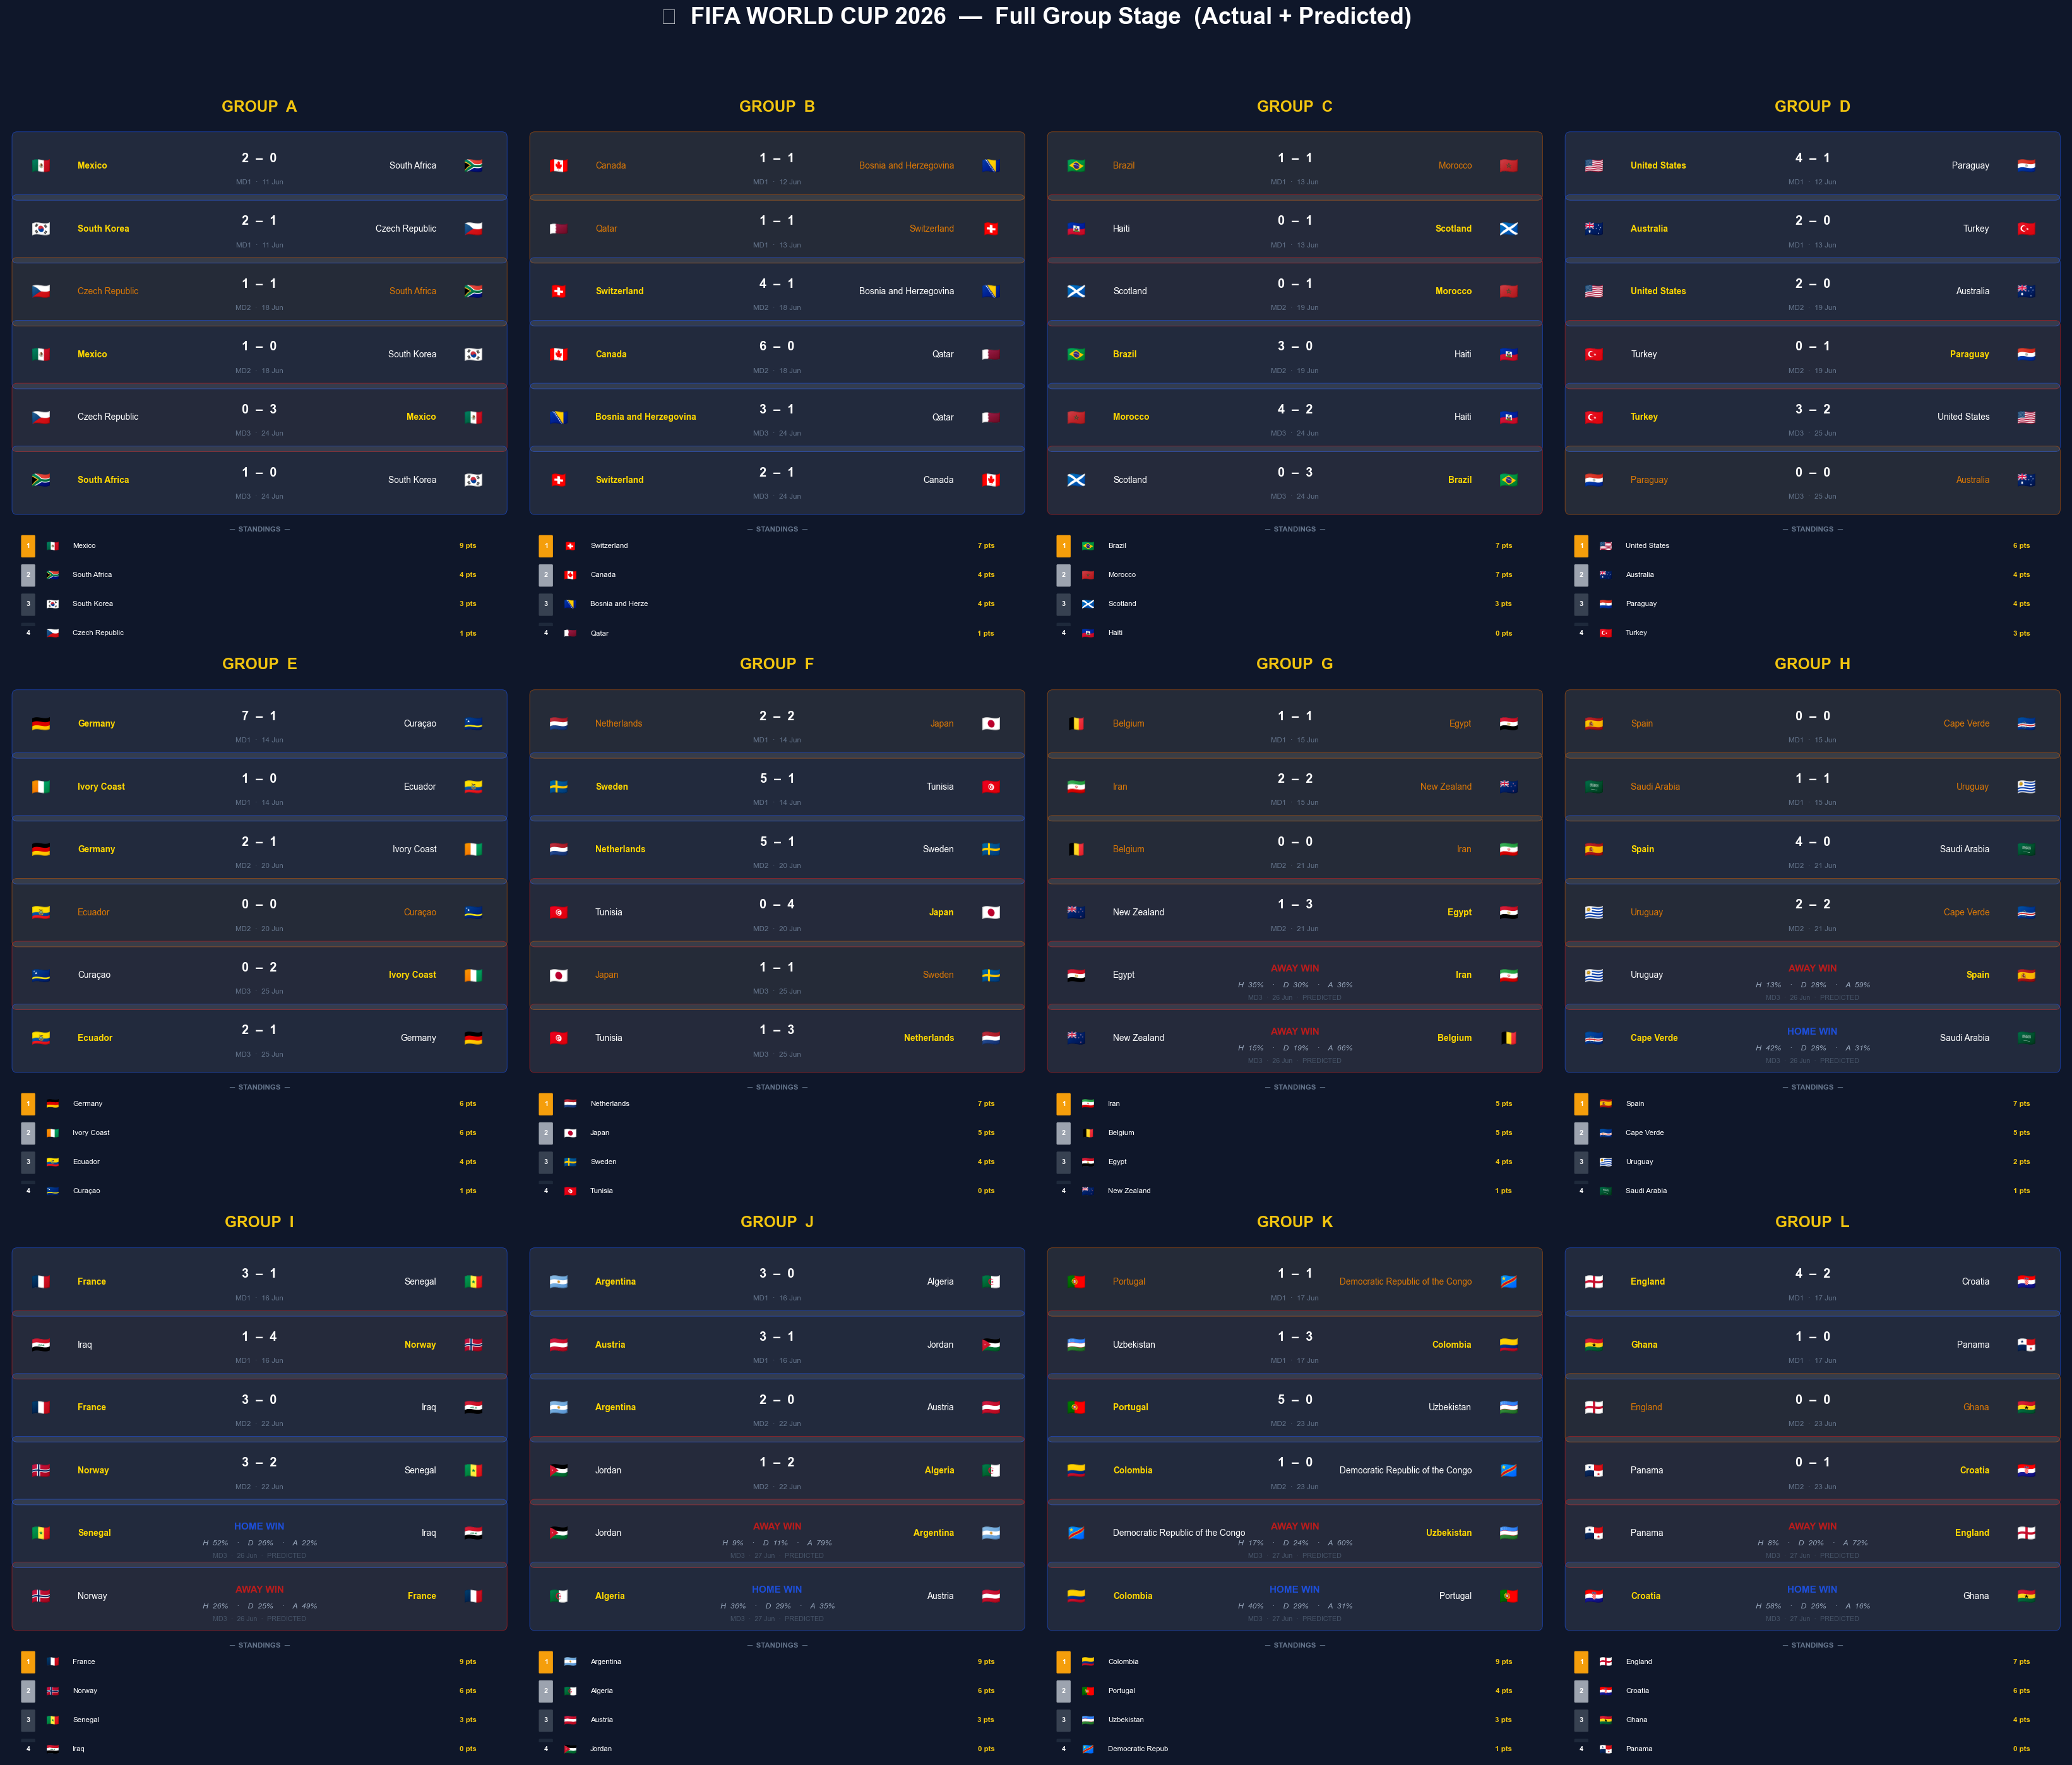

Saved wc2026_group_stage.png


In [9]:
# ── FIGURE 1: Group Stage Results Board ──────────────────────────────────────
RESULT_COLORS = {
    'home_win': ('#1D4ED8', '#DBEAFE18'),
    'away_win': ('#B91C1C', '#FEE2E218'),
    'draw':     ('#B45309', '#FEF3C718'),
}
LABEL_MAP = {'home_win': 'HOME WIN', 'away_win': 'AWAY WIN', 'draw': 'DRAW'}

# Include probability columns in the combined DataFrame
all_group = pd.concat([
    finished_group[['group','matchday','match_datetime','home_team','away_team',
                     'home_score','away_score','match_result','finished',
                     'prob_hw','prob_d','prob_aw']],
    pending_pred_df[['group','matchday','match_datetime','home_team','away_team',
                      'home_score','away_score','match_result','finished',
                      'prob_hw','prob_d','prob_aw']],
], ignore_index=True).sort_values(['group','matchday','match_datetime'])

groups_list = sorted(all_group['group'].unique())
ncols, nrows_g = 4, 3

fig = plt.figure(figsize=(30, nrows_g * 8.5))
fig.patch.set_facecolor('#0F172A')
fig.suptitle(
    '⚽  FIFA WORLD CUP 2026  —  Full Group Stage  (Actual + Predicted)',
    fontsize=24, fontweight='bold', color='white', y=0.995
)

for gi, grp in enumerate(groups_list):
    ax = fig.add_subplot(nrows_g, ncols, gi + 1)
    ax.set_facecolor('#1E293B')
    ax.set_xlim(0, 1)
    ax.axis('off')

    gdata = all_group[all_group['group'] == grp].reset_index(drop=True)
    n = len(gdata)
    row_h = 0.71 / max(n, 1)

    # Group header
    ax.text(0.5, 0.990, f'GROUP  {grp}', ha='center', va='top',
            fontsize=16, fontweight='bold', color='#F1C40F',
            transform=ax.transAxes)

    for ri, (_, mrow) in enumerate(gdata.iterrows()):
        yc = 0.925 - ri * row_h - row_h * 0.5
        res = mrow['match_result']
        dark, bg_col = RESULT_COLORS.get(res, ('#374151', '#F3F4F611'))
        predicted = not mrow['finished']

        # Match card background
        bx = FancyBboxPatch(
            (0.02, yc - row_h * 0.46), 0.96, row_h * 0.92,
            boxstyle='round,pad=0.01', linewidth=0.6,
            facecolor=bg_col, edgecolor=dark + 'AA',
            transform=ax.transAxes, clip_on=False
        )
        ax.add_patch(bx)

        h_bold = 'bold' if res == 'home_win' else 'normal'
        a_bold = 'bold' if res == 'away_win' else 'normal'
        d_bold = 'bold' if res == 'draw' else 'normal'
        h_col  = '#FFD700' if res == 'home_win' else ('white' if res != 'draw' else '#D97706')
        a_col  = '#FFD700' if res == 'away_win' else ('white' if res != 'draw' else '#D97706')

        # Home flag + name
        hf = get_flag_img(mrow['home_team'])
        if hf is not None:
            ib = OffsetImage(hf, zoom=0.56); ib.image.axes = ax
            ax.add_artist(AnnotationBbox(
                ib, (0.05, yc), xycoords=ax.transAxes,
                frameon=False, box_alignment=(0, 0.5), clip_on=False
            ))
        ax.text(0.14, yc, mrow['home_team'], ha='left', va='center',
                fontsize=9, fontweight=h_bold, color=h_col,
                transform=ax.transAxes)

        # Away flag + name
        af = get_flag_img(mrow['away_team'])
        if af is not None:
            ib = OffsetImage(af, zoom=0.56); ib.image.axes = ax
            ax.add_artist(AnnotationBbox(
                ib, (0.94, yc), xycoords=ax.transAxes,
                frameon=False, box_alignment=(1, 0.5), clip_on=False
            ))
        ax.text(0.85, yc, mrow['away_team'], ha='right', va='center',
                fontsize=9, fontweight=a_bold, color=a_col,
                transform=ax.transAxes)

        # Centre: score or prediction label
        if mrow['finished'] and pd.notna(mrow.get('home_score')):
            score_txt = f"{int(mrow['home_score'])}  –  {int(mrow['away_score'])}"
            ax.text(0.5, yc + row_h * 0.12, score_txt, ha='center', va='center',
                    fontsize=13, fontweight='bold', color='white',
                    transform=ax.transAxes)
            day_str = pd.to_datetime(mrow['match_datetime']).strftime('%d %b')
            ax.text(0.5, yc - row_h * 0.26,
                    f"MD{int(mrow['matchday'])}  ·  {day_str}",
                    ha='center', va='center', fontsize=7.5, color='#64748B',
                    transform=ax.transAxes)
        else:
            # Predicted match — result label
            ax.text(0.5, yc + row_h * 0.10, LABEL_MAP.get(res, '?'),
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=dark,
                    transform=ax.transAxes)

            # Probability display: H% · D% · A%
            if pd.notna(mrow.get('prob_hw')):
                hw, dr, aw = mrow['prob_hw'], mrow['prob_d'], mrow['prob_aw']
                prob_txt = (
                    f"H  {hw:.0%}    ·    D  {dr:.0%}    ·    A  {aw:.0%}"
                )
                ax.text(0.5, yc - row_h * 0.16, prob_txt,
                        ha='center', va='center',
                        fontsize=8, color='#94A3B8',
                        style='italic', transform=ax.transAxes)

            day_str = pd.to_datetime(mrow['match_datetime']).strftime('%d %b')
            ax.text(0.5, yc - row_h * 0.36,
                    f"MD{int(mrow['matchday'])}  ·  {day_str}  ·  PREDICTED",
                    ha='center', va='center',
                    fontsize=7, color='#475569',
                    transform=ax.transAxes)

    # ── Mini standings ────────────────────────────────────────────
    stand = standings.get(grp, pd.DataFrame())
    if not stand.empty:
        y_base = 0.925 - n * row_h - 0.028
        ax.text(0.5, y_base, '─  STANDINGS  ─', ha='center', va='top',
                fontsize=7.5, color='#64748B', fontweight='bold',
                transform=ax.transAxes)
        for ri2, (_, srow) in enumerate(stand.iterrows()):
            ys = y_base - 0.036 - ri2 * 0.055
            rank_col = ['#F59E0B', '#9CA3AF', '#374151', '#1E293B'][min(ri2, 3)]
            ax.add_patch(FancyBboxPatch(
                (0.03, ys - 0.020), 0.024, 0.038,
                boxstyle='round,pad=0.002', facecolor=rank_col, edgecolor='none',
                transform=ax.transAxes
            ))
            ax.text(0.042, ys, str(ri2 + 1), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold',
                    transform=ax.transAxes)
            sf = get_flag_img(srow['team'])
            if sf is not None:
                ib = OffsetImage(sf, zoom=0.38); ib.image.axes = ax
                ax.add_artist(AnnotationBbox(
                    ib, (0.09, ys), xycoords=ax.transAxes,
                    frameon=False, box_alignment=(0.5, 0.5), clip_on=False
                ))
            ax.text(0.13, ys, srow['team'][:16], ha='left', va='center',
                    fontsize=7.5, color='white', transform=ax.transAxes)
            ax.text(0.93, ys, f"{int(srow['pts'])} pts", ha='right', va='center',
                    fontsize=7.5, color='#F1C40F', fontweight='bold',
                    transform=ax.transAxes)

plt.tight_layout(rect=[0, 0, 1, 0.972])
plt.savefig('wc2026_group_stage.png', dpi=150, bbox_inches='tight',
            facecolor='#0F172A')
plt.show()
print("Saved wc2026_group_stage.png")


## Figure 2 — Full Knockout Bracket

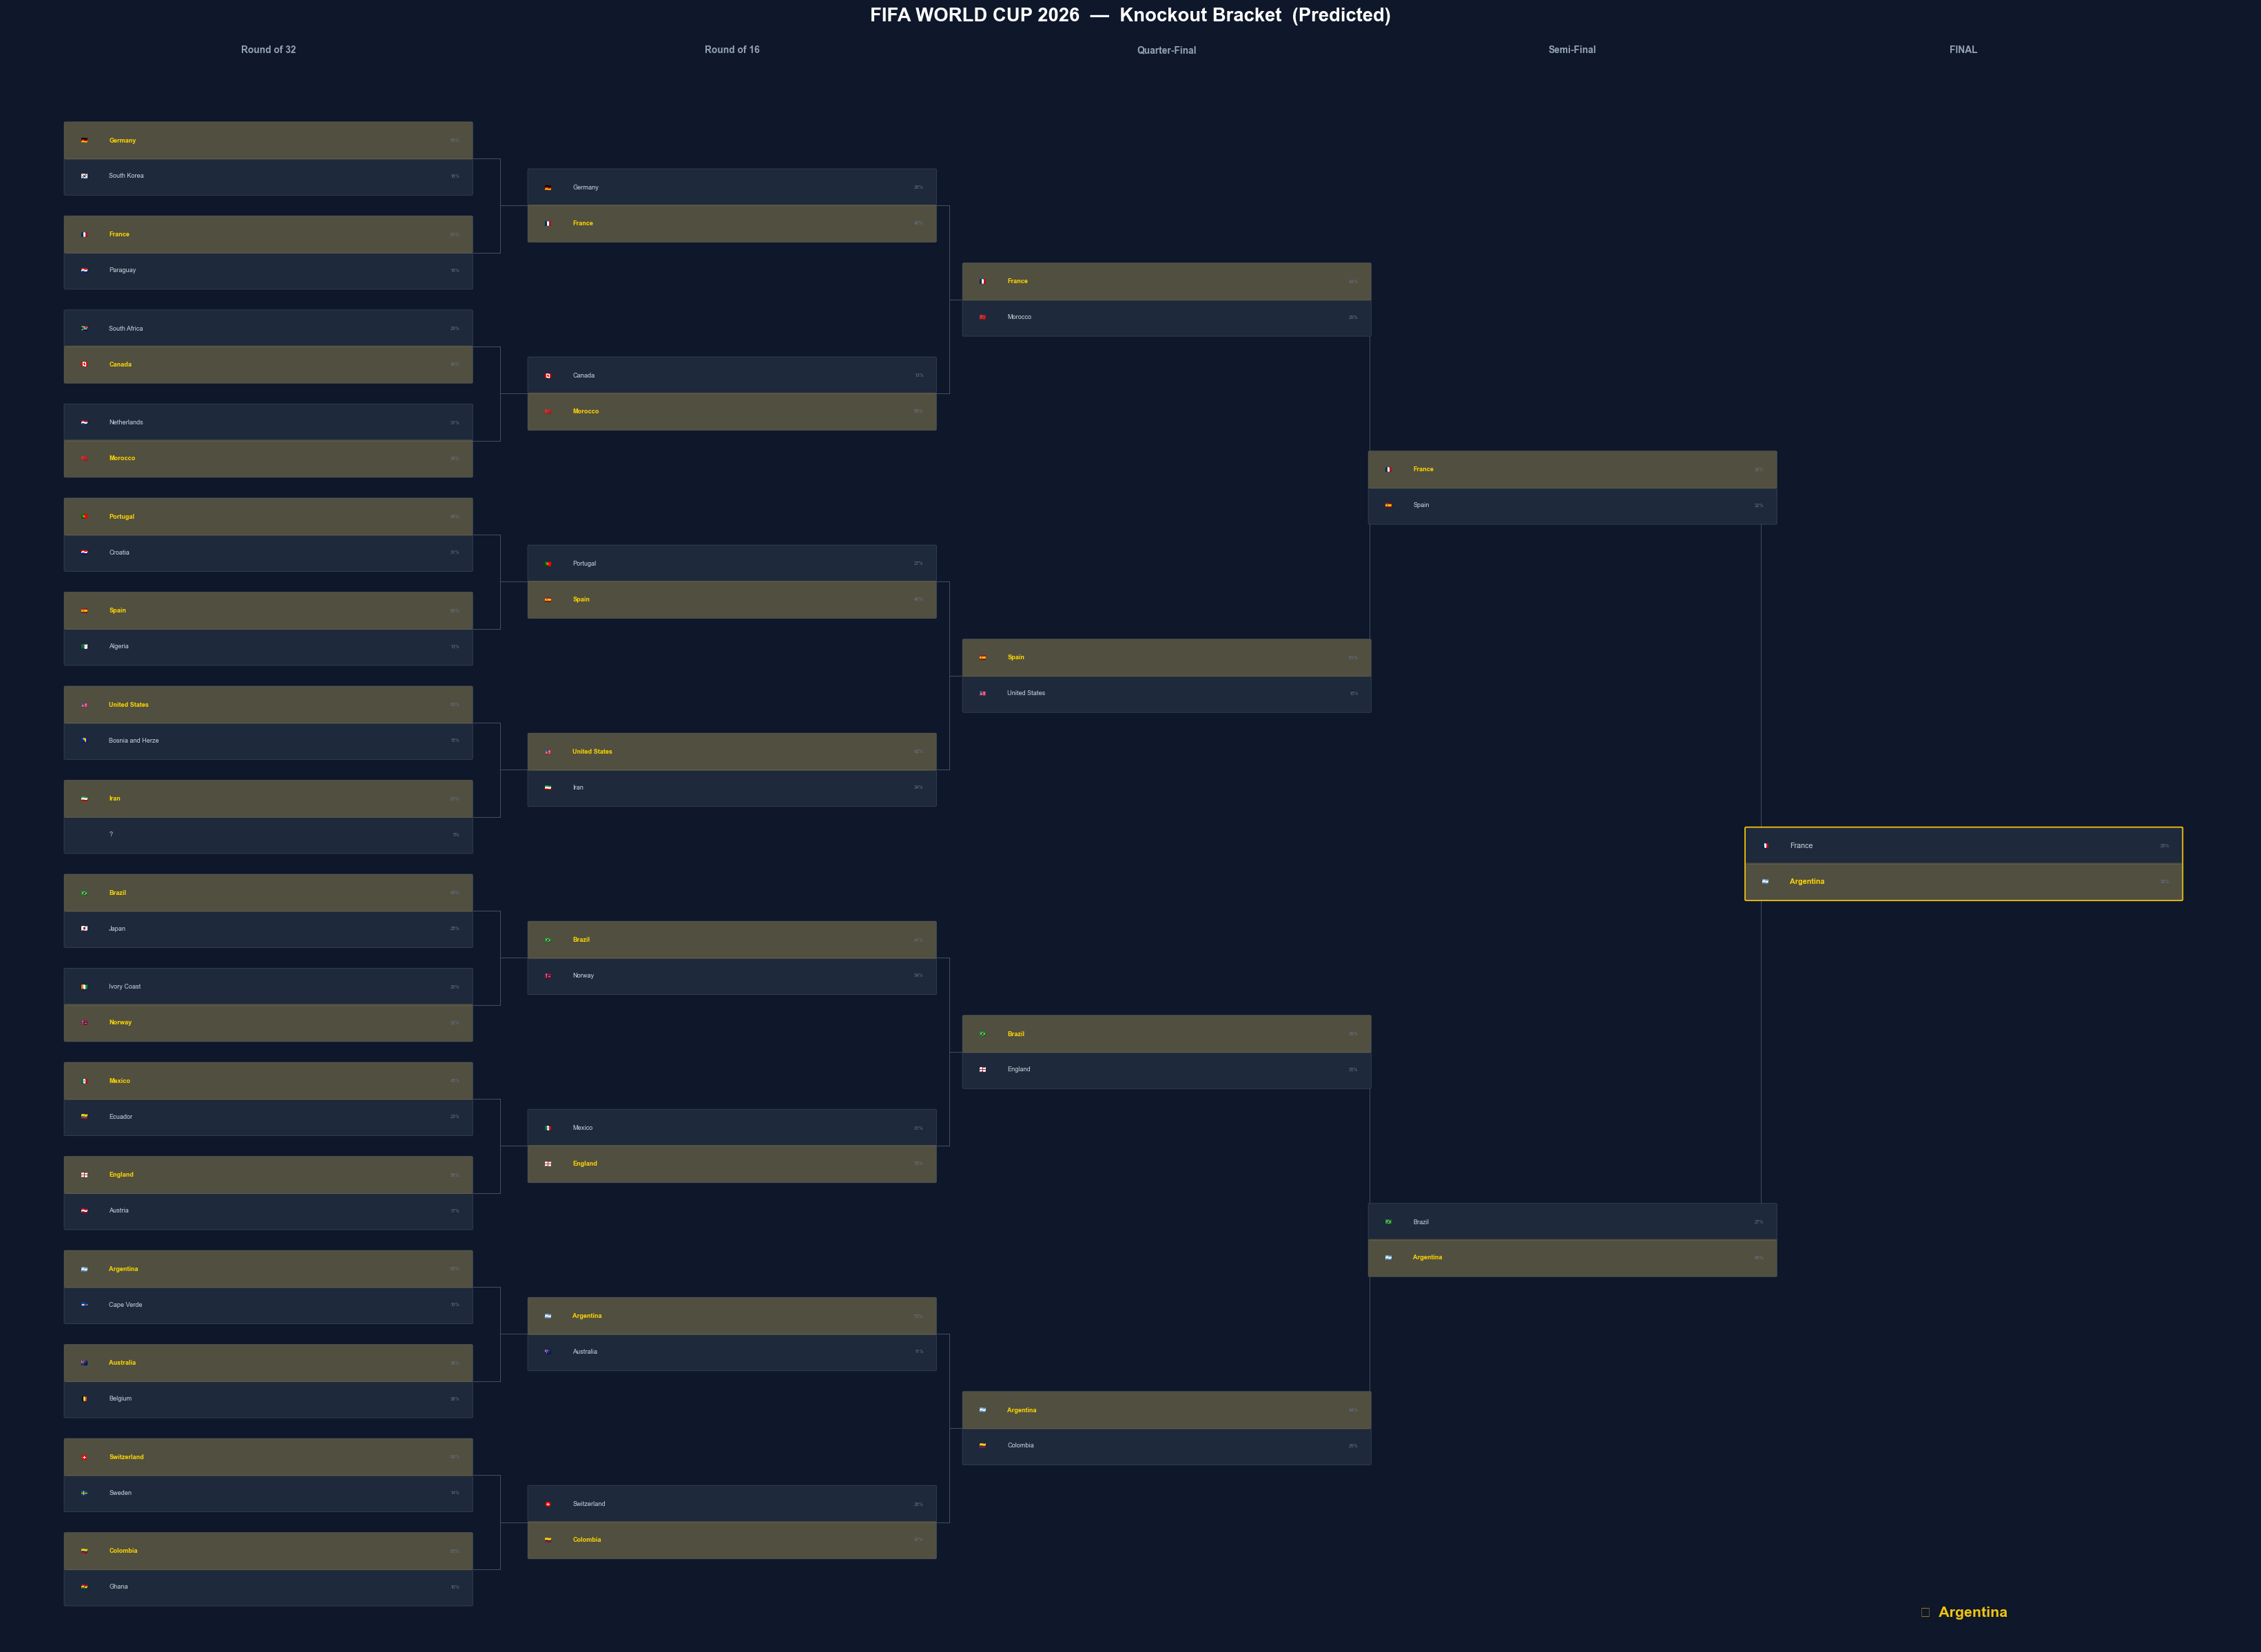

Saved wc2026_bracket.png


In [10]:
# ── FIGURE 2: Full Knockout Bracket ──────────────────────────────────────────
# Bracket layout (match_id -> y-centre, round -> x-centre)
# Top half feeds SF 101, Bottom half feeds SF 102
BRACKET_ORDER = {
    # R32 y-positions (top half: y=8..15, bottom half: y=0..7)
    74: 15, 77: 14, 73: 13, 75: 12,
    83: 11, 84: 10, 81: 9,  82: 8,
    76: 7,  78: 6,  79: 5,  80: 4,
    86: 3,  88: 2,  85: 1,  87: 0,
    # R16
    89: 14.5, 90: 12.5, 93: 10.5, 94: 8.5,
    91: 6.5,  92: 4.5,  95: 2.5,  96: 0.5,   # note 95/96 reversed to match bracket
    # QF
    97: 13.5, 98: 9.5, 99: 5.5, 100: 1.5,
    # SF
    101: 11.5, 102: 3.5,
    # Final
    104: 7.5,
}
ROUND_X = {
    'r32': 0.2, 'r16': 3.4, 'qf': 6.4, 'sf': 9.2, 'final': 11.8,
}
MID_TYPE = {
    **{m: 'r32'   for m in [73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88]},
    **{m: 'r16'   for m in [89,90,91,92,93,94,95,96]},
    **{m: 'qf'    for m in [97,98,99,100]},
    **{m: 'sf'    for m in [101,102]},
    104: 'final',
}
CARD_W = {'r32': 2.8, 'r16': 2.8, 'qf': 2.8, 'sf': 2.8, 'final': 3.0}
CARD_H = 0.38  # half-height per team row

# connector pairs: (match_id_a, match_id_b) -> match_id_next
CONNECTORS = [
    (74,77,89),(73,75,90),(83,84,93),(81,82,94),
    (76,78,91),(79,80,92),(86,88,95),(85,87,96),
    (89,90,97),(93,94,98),(91,92,99),(95,96,100),
    (97,98,101),(99,100,102),(101,102,104),
]

fig, ax = plt.subplots(figsize=(30, 22))
fig.patch.set_facecolor('#0F172A')
ax.set_facecolor('#0F172A')
ax.set_xlim(-0.2, 15.3)
ax.set_ylim(-0.8, 16.3)
ax.axis('off')
fig.suptitle('FIFA WORLD CUP 2026  —  Knockout Bracket  (Predicted)',
             fontsize=18, fontweight='bold', color='white', y=0.99)

# Round labels
for rnd, xc in ROUND_X.items():
    lbl = {'r32':'Round of 32','r16':'Round of 16','qf':'Quarter-Final',
           'sf':'Semi-Final','final':'FINAL'}[rnd]
    cw = CARD_W[rnd]
    ax.text(xc + cw/2, 16.1, lbl, ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#94A3B8')

def draw_card(ax, mid):
    if mid not in KO_RESULTS: return
    d = KO_RESULTS[mid]
    rnd = MID_TYPE[mid]
    xc = ROUND_X[rnd]
    yc = BRACKET_ORDER[mid]
    cw = CARD_W[rnd]
    home, away, winner = d['home'], d['away'], d['winner']

    # outer box
    is_final = (rnd == 'final')
    edge_col = '#F1C40F' if is_final else '#334155'
    ax.add_patch(FancyBboxPatch((xc, yc-CARD_H), cw, 2*CARD_H,
        boxstyle='round,pad=0.01', lw=1.2 if is_final else 0.6,
        facecolor='#1E293B', edgecolor=edge_col, zorder=2))
    ax.plot([xc, xc+cw], [yc, yc], color='#334155', lw=0.5, zorder=3)

    for team, y_offset, is_top in [(home, CARD_H/2, True), (away, -CARD_H/2, False)]:
        won = (team == winner)
        if won:
            yy = yc if is_top else yc-CARD_H
            ax.add_patch(FancyBboxPatch((xc, yy), cw, CARD_H,
                boxstyle='round,pad=0.01', facecolor='#c9a84c', edgecolor='none',
                alpha=0.30, zorder=3))
        flag = get_flag_img(team)
        if flag is not None:
            ib = OffsetImage(flag, zoom=0.18); ib.image.axes = ax
            ax.add_artist(AnnotationBbox(ib,(xc+0.13, yc+y_offset),
                frameon=False, box_alignment=(0.5,0.5), zorder=4))
        col  = '#FFD700' if won else ('#94A3B8' if not won else 'white')
        col  = '#FFD700' if won else '#CBD5E1'
        fw   = 'bold' if won else 'normal'
        fs   = 6 if rnd != 'final' else 7
        name = team[:16]
        ax.text(xc+0.30, yc+y_offset, name, va='center', ha='left',
                fontsize=fs, fontweight=fw, color=col, zorder=5)
        p_val = d['prob_hw'] if is_top else d['prob_aw']
        if not d['finished']:
            ax.text(xc+cw-0.08, yc+y_offset, f'{p_val:.0%}',
                    va='center', ha='right', fontsize=4.5, color='#64748B', zorder=5)

for mid in BRACKET_ORDER:
    draw_card(ax, mid)

# Draw connector lines
for triple in CONNECTORS:
    ma, mb, mc = triple
    if ma not in BRACKET_ORDER or mb not in BRACKET_ORDER or mc not in BRACKET_ORDER:
        continue
    rnd_a = MID_TYPE[ma]
    cw_a  = CARD_W[rnd_a]
    xa_right = ROUND_X[rnd_a] + cw_a
    ya = BRACKET_ORDER[ma]
    yb = BRACKET_ORDER[mb]
    yc_dest = BRACKET_ORDER[mc]
    xc_left = ROUND_X[MID_TYPE[mc]]
    xmid = (xa_right + xc_left) / 2
    # line from card A
    ax.plot([xa_right, xmid], [ya, ya], color='#475569', lw=0.6, zorder=1)
    # line from card B
    ax.plot([xa_right, xmid], [yb, yb], color='#475569', lw=0.6, zorder=1)
    # vertical
    ax.plot([xmid, xmid], [ya, yb], color='#475569', lw=0.6, zorder=1)
    # line to next card
    ax.plot([xmid, xc_left], [yc_dest, yc_dest], color='#475569', lw=0.6, zorder=1)

# Champion annotation
champ = KO_RESULTS[104]['winner']
ax.text(ROUND_X['final']+CARD_W['final']/2, -0.4,
        f'\U0001f3c6  {champ}', ha='center', va='top',
        fontsize=14, fontweight='bold', color='#F1C40F')

plt.tight_layout()
plt.savefig('wc2026_bracket.png', dpi=130, bbox_inches='tight', facecolor='#0F172A')
plt.show()
print("Saved wc2026_bracket.png")

## Figure 3 — Monte Carlo Champion Probabilities

Running Monte Carlo simulation…


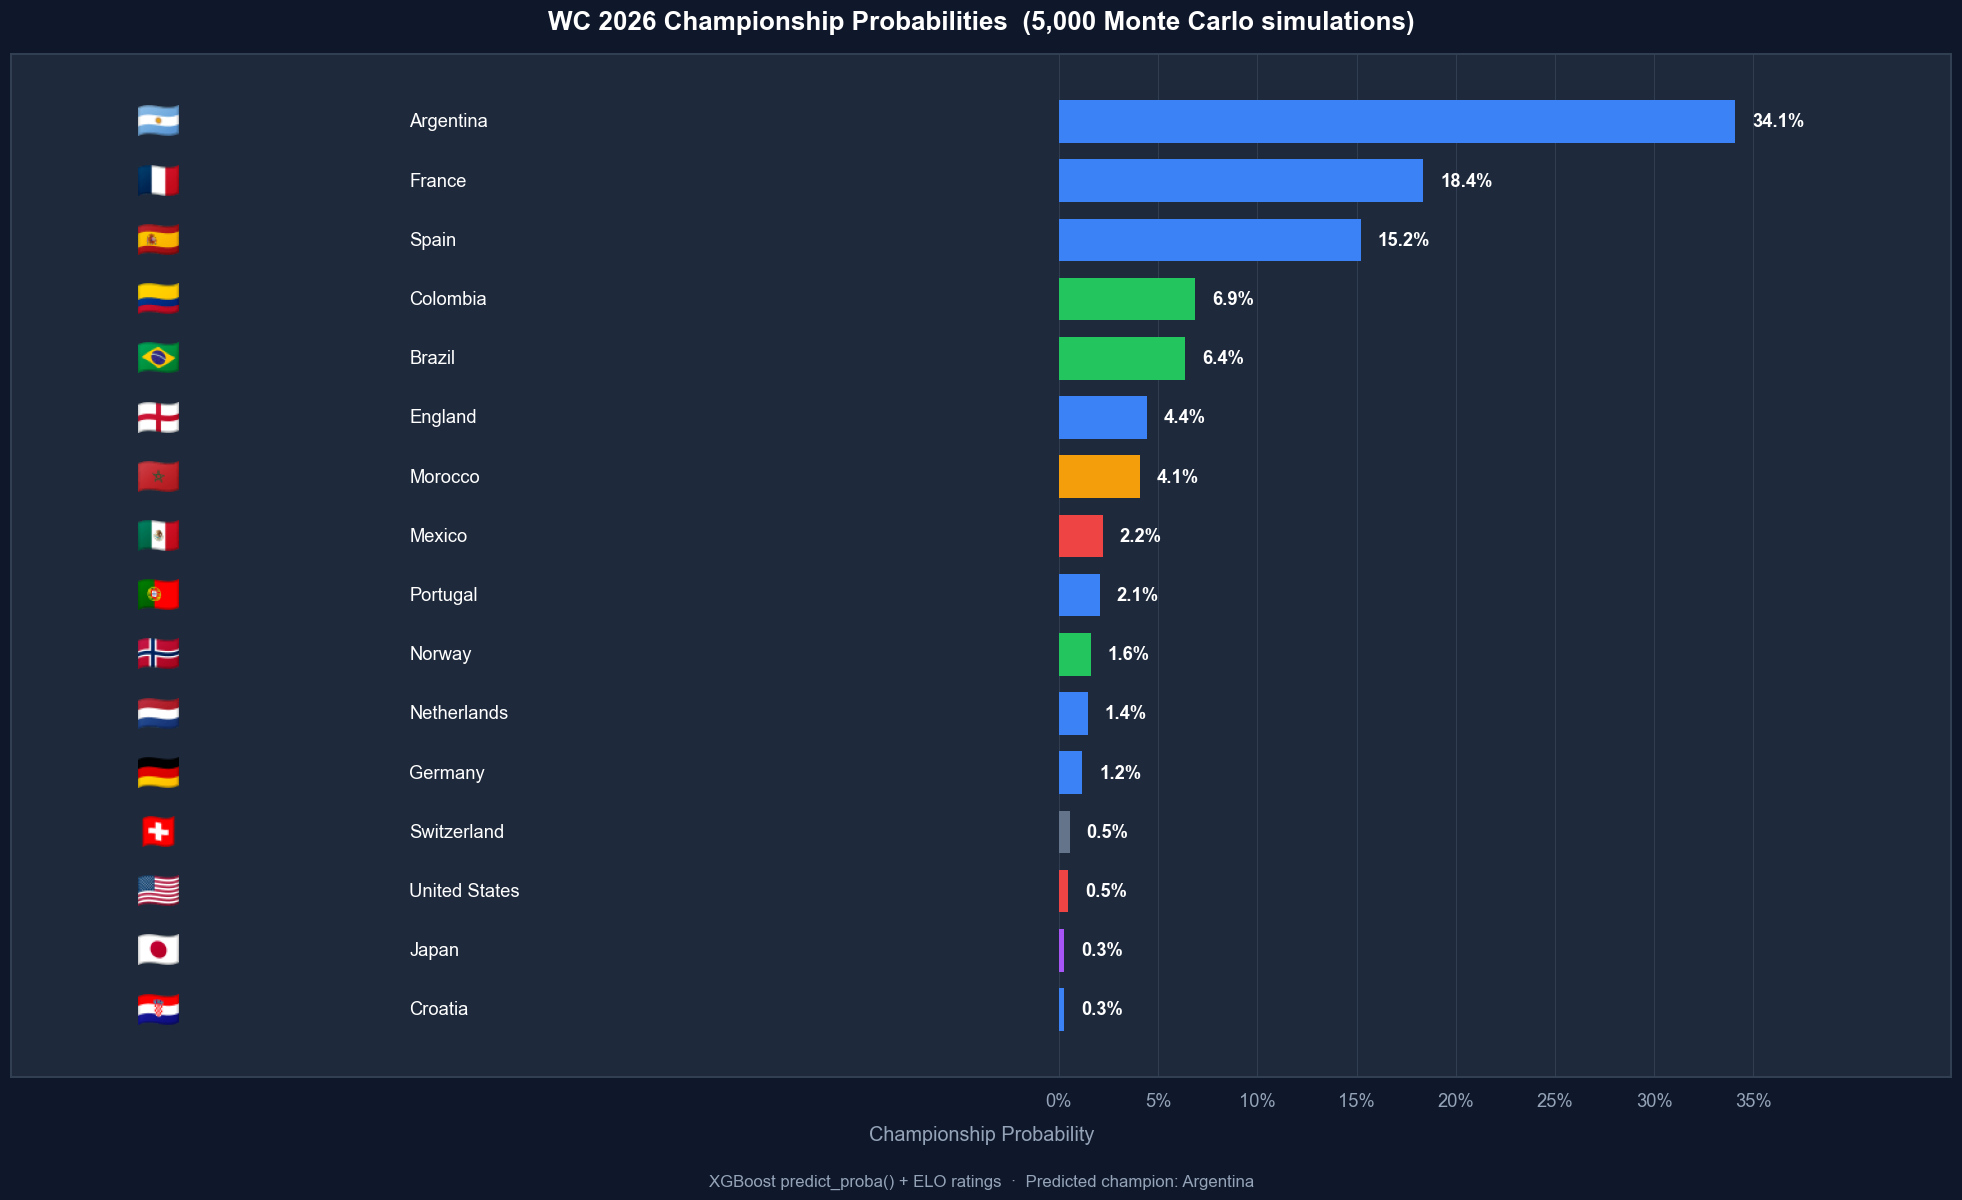


Top 5 champion probabilities:
Argentina    34.1%
France       18.4%
Spain        15.2%
Colombia      6.9%
Brazil        6.4%


In [11]:
# ── FIGURE 3: Monte Carlo Champion Probability ───────────────────────────────
import random
random.seed(42)
N_SIMS = 5000

def mc_sim():
    winners = {}
    for mid in [73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88]:
        if mid not in KO_RESULTS: continue
        d = KO_RESULTS[mid]
        if d['finished']:
            winners[mid] = d['winner']
        else:
            p = predict_probs(d['home'], d['away'], neutral=True)
            r = random.random()
            if r < p[0]:
                winners[mid] = d['home']
            elif r < p[0] + p[2]:
                winners[mid] = d['away']
            else:
                winners[mid] = d['home'] if p[0] >= p[2] else d['away']

    R16_PAIRS  = [(74,77,89),(73,75,90),(83,84,93),(81,82,94),
                  (76,78,91),(79,80,92),(86,88,95),(85,87,96)]
    QF_PAIRS   = [(89,90,97),(93,94,98),(91,92,99),(95,96,100)]
    SF_PAIRS   = [(97,98,101),(99,100,102)]
    FINAL_PAIR = [(101,102,104)]

    for pairs in [R16_PAIRS, QF_PAIRS, SF_PAIRS, FINAL_PAIR]:
        for ma, mb, mc in pairs:
            h = winners.get(ma, '?')
            a = winners.get(mb, '?')
            if h == '?' or a == '?':
                winners[mc] = '?'
                continue
            if KO_RESULTS.get(mc, {}).get('finished'):
                winners[mc] = KO_RESULTS[mc]['winner']
            else:
                p = predict_probs(h, a, neutral=True)
                r = random.random()
                if r < p[0]:
                    winners[mc] = h
                elif r < p[0] + p[2]:
                    winners[mc] = a
                else:
                    winners[mc] = h if p[0] >= p[2] else a
    return winners.get(104, '?')

print("Running Monte Carlo simulation…")
champ_counts = defaultdict(int)
for _ in range(N_SIMS):
    champ_counts[mc_sim()] += 1

champ_probs = pd.Series(dict(champ_counts)).sort_values(ascending=False) / N_SIMS
champ_probs = champ_probs[champ_probs.index != "?"]   # remove unresolved bracket slots
champ_probs = champ_probs / champ_probs.sum()           # renormalize to 100%
top16 = champ_probs.head(16).sort_values()   # ascending → longest bar at top

CONF_COLORS = {
    'Argentina':   '#3B82F6', 'Spain':        '#3B82F6', 'France':      '#3B82F6',
    'Germany':     '#3B82F6', 'Portugal':     '#3B82F6', 'England':     '#3B82F6',
    'Netherlands': '#3B82F6', 'Croatia':      '#3B82F6', 'Belgium':     '#3B82F6',
    'Brazil':      '#22C55E', 'Colombia':     '#22C55E', 'Ecuador':     '#22C55E',
    'Uruguay':     '#22C55E', 'Norway':       '#22C55E',
    'Morocco':     '#F59E0B', 'Senegal':      '#F59E0B', 'Egypt':       '#F59E0B',
    'Japan':       '#A855F7', 'South Korea':  '#A855F7', 'Australia':   '#A855F7',
    'United States':'#EF4444','Mexico':       '#EF4444', 'Canada':      '#EF4444',
}
bar_colors = [CONF_COLORS.get(t, '#64748B') for t in top16.index]

# ── Figure & axes ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 11))
fig.patch.set_facecolor('#0F172A')
ax.set_facecolor('#1E293B')
for sp in ax.spines.values():
    sp.set_color('#334155')

# Reserve left space (in data coordinates) for flag + team name
x_max = float(top16.max())
LEFT_SPACE = x_max * 1.55      # negative x range to the left of 0
ax.set_xlim(-LEFT_SPACE, x_max * 1.32)

ax.xaxis.grid(True, color='#334155', lw=0.6)
ax.set_axisbelow(True)
ax.yaxis.set_visible(False)

# Only show non-negative x-ticks as percentages
pos_ticks = [i * 0.05 for i in range(int(x_max / 0.05) + 2) if i * 0.05 <= x_max * 1.25]
ax.set_xticks(pos_ticks)
ax.set_xticklabels([f'{v:.0%}' for v in pos_ticks], color='#94A3B8', fontsize=12)
ax.tick_params(axis='x', colors='#94A3B8', labelsize=12)

# Bars
ax.barh(range(len(top16)), top16.values, color=bar_colors,
        edgecolor='none', height=0.72, left=0)

# ── Labels: flag THEN name (left-to-right), then % value after bar ─
FLAG_X = -LEFT_SPACE * 0.86     # flag image centre (data coords)
NAME_X = -LEFT_SPACE * 0.62     # team name left edge (data coords)

for i, (team, val) in enumerate(top16.items()):
    flag = get_flag_img(team, size='32x24')
    if flag is not None:
        ib = OffsetImage(flag, zoom=0.82)
        ib.image.axes = ax
        ax.add_artist(AnnotationBbox(
            ib, (FLAG_X, i), xycoords='data',
            frameon=False, box_alignment=(0.5, 0.5), clip_on=False, zorder=5
        ))
    ax.text(NAME_X, i, team, va='center', ha='left',
            fontsize=12, color='white', fontweight='500', zorder=6)
    ax.text(val + x_max * 0.025, i, f'{val:.1%}',
            va='center', ha='left',
            fontsize=12, color='white', fontweight='bold', zorder=6)

ax.set_xlabel('Championship Probability', color='#94A3B8', fontsize=13, labelpad=10)
ax.set_title(
    f'WC 2026 Championship Probabilities  ({N_SIMS:,} Monte Carlo simulations)',
    fontsize=17, fontweight='bold', color='white', pad=16
)
fig.text(
    0.5, 0.012,
    f'XGBoost predict_proba() + ELO ratings  ·  Predicted champion: {champ_probs.index[0]}',
    ha='center', fontsize=11, color='#94A3B8'
)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('wc2026_champion_probs.png', dpi=160, bbox_inches='tight',
            facecolor='#0F172A')
plt.show()
print(f"\nTop 5 champion probabilities:")
print(champ_probs.head(5).map(lambda x: f'{x:.1%}').to_string())
